# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [1]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [6]:
print("Estadísticas después del escalado MinMax:")
data_minmax.describe()

Estadísticas después del escalado MinMax:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


In [5]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


Los valores más pequeños en la columna se ajusten al límite inferior (por ejemplo, 0) y los valores más grandes al límite superior (por ejemplo, 1), mientras que los valores intermedios se escalan proporcionalmente dentro de ese rango.

### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

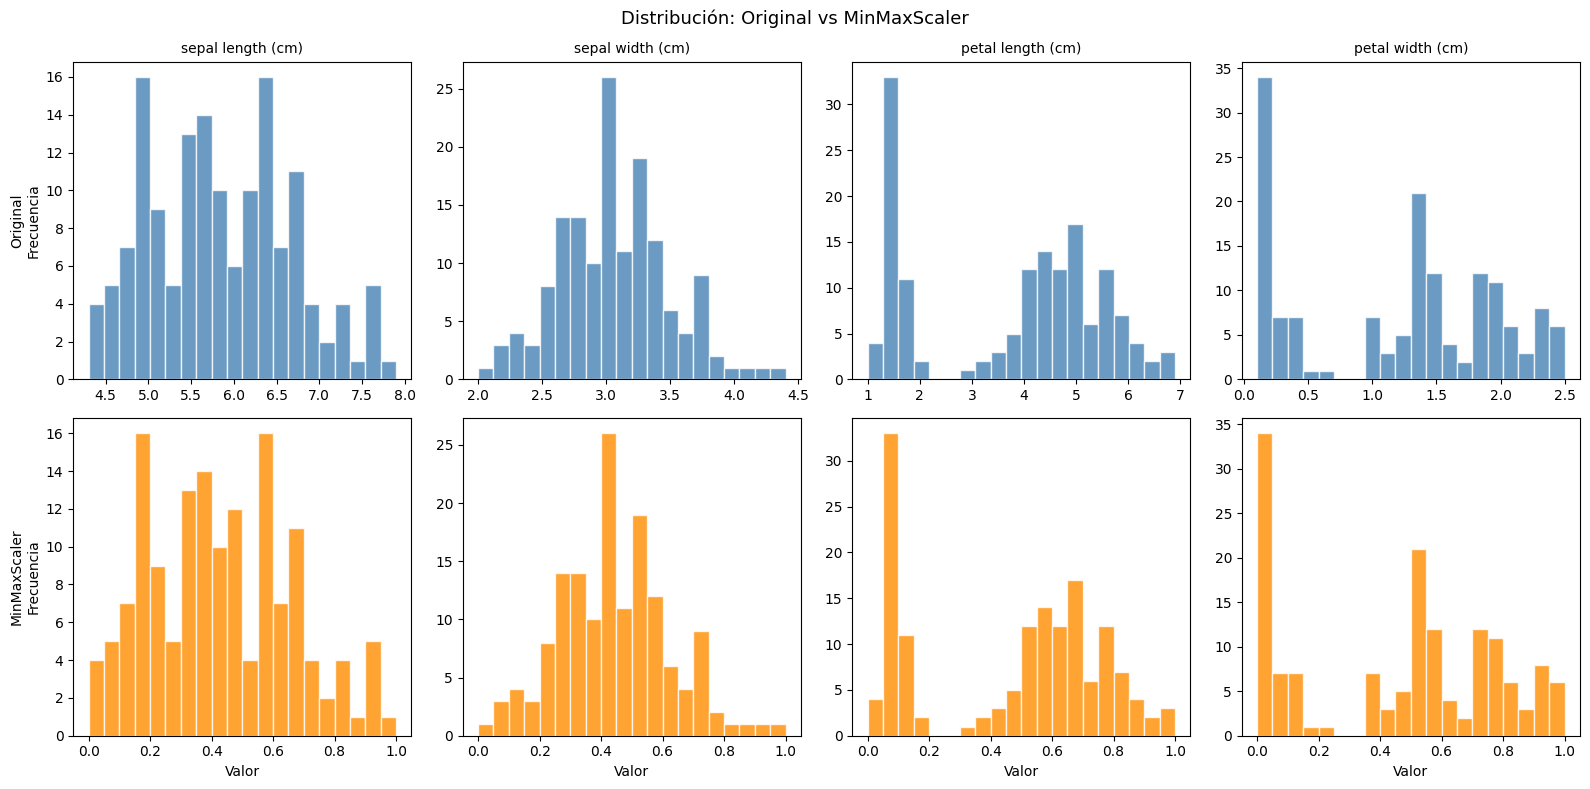

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

columnas = data.columns

for i, col in enumerate(columnas):
    # Fila 0: datos originales
    axes[0, i].hist(data[col], bins=20, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}', fontsize=10)
    axes[0, i].set_ylabel('Frecuencia' if i == 0 else '')

    # Fila 1: datos normalizados
    axes[1, i].hist(data_minmax[col], bins=20, color='darkorange', edgecolor='white', alpha=0.8)
    axes[1, i].set_xlabel('Valor')
    axes[1, i].set_ylabel('Frecuencia' if i == 0 else '')

# Etiquetas de fila
axes[0, 0].set_ylabel('Original\nFrecuencia')
axes[1, 0].set_ylabel('MinMaxScaler\nFrecuencia')

plt.suptitle('Distribución: Original vs MinMaxScaler', fontsize=13)
plt.tight_layout()
plt.show()

3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

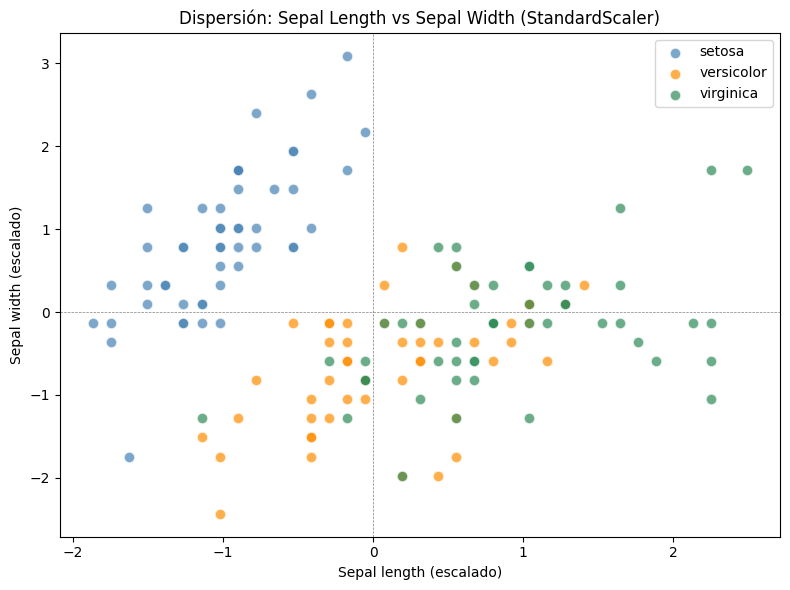

In [8]:
from sklearn.preprocessing import StandardScaler

# Aplicar StandardScaler
std_scaler = StandardScaler()
data_std = pd.DataFrame(std_scaler.fit_transform(data), columns=data.columns)

# Agregar la especie para colorear los puntos
data_std['species'] = iris.target

# Gráfica de dispersión
colores = ['steelblue', 'darkorange', 'seagreen']
especies = iris.target_names  # ['setosa', 'versicolor', 'virginica']

fig, ax = plt.subplots(figsize=(8, 6))

for i, especie in enumerate(especies):
    subset = data_std[data_std['species'] == i]
    ax.scatter(
        subset['sepal length (cm)'],
        subset['sepal width (cm)'],
        label=especie,
        color=colores[i],
        alpha=0.7,
        edgecolors='white',
        s=60
    )

ax.set_xlabel('Sepal length (escalado)')
ax.set_ylabel('Sepal width (escalado)')
ax.set_title('Dispersión: Sepal Length vs Sepal Width (StandardScaler)')
ax.legend()
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

Personalmente creo que el escalado Standar es mejor ya que se requiere que los datos sigan una distribución centrada y escalada